## Pull BigQuery Dataset:

In [17]:
# ============================================================
# Cell 1: Imports, Auth, Config
# ============================================================
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from google.oauth2 import service_account
from google.cloud import bigquery

# ── Styling ─────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.float_format", "{:,.2f}".format)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

# ── Config ───────────────────────────────────────────────────
PROJECT_ID = "recosys-489001"
DATASET_ID = "recosys"
TABLE_ID   = "events_raw"
TABLE_REF  = f"{PROJECT_ID}.{DATASET_ID}.{TABLE_ID}"
KEY_PATH   = os.path.expanduser("C:\\Users\\Patron\\Documents\\GitHub\\RecoSys\\secrets\\recosys-service-account.json")

# ── Auth ─────────────────────────────────────────────────────
credentials = service_account.Credentials.from_service_account_file(
    KEY_PATH,
    scopes=["https://www.googleapis.com/auth/cloud-platform"],
)
bq = bigquery.Client(project=PROJECT_ID, credentials=credentials)
print(f"✅ Connected — {credentials.service_account_email}")

✅ Connected — 921967012784-compute@developer.gserviceaccount.com


In [18]:
# ============================================================
# Cell 2: Query Helper
# ============================================================
import time

# Simple in-memory cache so re-running cells doesn't re-bill you
_cache = {}

def run_query(sql: str, label: str = "", use_cache: bool = True) -> pd.DataFrame:
    """
    Run a BigQuery SQL query and return a DataFrame.
    
    - Dry-runs first to print bytes that will be scanned.
    - Caches results in memory by label (set use_cache=False to force refresh).
    - Prints elapsed time on completion.
    """
    cache_key = label or sql[:120]
    
    if use_cache and cache_key in _cache:
        df = _cache[cache_key]
        print(f"[cache] '{label}' → {len(df):,} rows")
        return df

    # ── Dry run: estimate cost before executing ──────────────
    dry_config = bigquery.QueryJobConfig(dry_run=True, use_query_cache=False)
    dry_job = bq.query(sql, job_config=dry_config)
    bytes_scanned = dry_job.total_bytes_processed
    gb_scanned    = bytes_scanned / 1e9
    cost_est      = (bytes_scanned / 1e12) * 5  # $5 per TB

    print(f"{'─'*60}")
    if label:
        print(f"  Query  : {label}")
    print(f"  Scan   : {gb_scanned:.2f} GB  (~${cost_est:.4f})")
    
    # Warn but don't block — you decide whether to proceed
    if gb_scanned > 10:
        print(f"  ⚠️  Large scan — confirm this is intentional")

    # ── Execute ──────────────────────────────────────────────
    t0  = time.time()
    job = bq.query(sql)
    df  = job.result().to_dataframe()
    elapsed = time.time() - t0

    print(f"  Rows   : {len(df):,}")
    print(f"  Time   : {elapsed:.1f}s")
    print(f"{'─'*60}")

    if label:
        _cache[cache_key] = df
    return df


def clear_cache():
    _cache.clear()
    print("Cache cleared.")

In [19]:
# ============================================================
# Cell 3: Table metadata — zero cost
# ============================================================
table = bq.get_table(TABLE_REF)
print(f"Table      : {table.full_table_id}")
print(f"Rows       : {table.num_rows:,}")
print(f"Size       : {table.num_bytes/1e9:.2f} GB")
print(f"Created    : {table.created}")
print(f"Modified   : {table.modified}")
print(f"\nSchema:")
for f in table.schema:
    nullable = "NULLABLE" if f.is_nullable else "REQUIRED"
    print(f"  {f.name:<20} {f.field_type:<12} {nullable}")

Table      : recosys-489001:recosys.events_raw
Rows       : 288,779,227
Size       : 32.03 GB
Created    : 2026-03-06 02:10:45.210000+00:00
Modified   : 2026-03-06 02:10:45.210000+00:00

Schema:
  event_time           TIMESTAMP    NULLABLE
  event_type           STRING       NULLABLE
  product_id           INTEGER      NULLABLE
  category_id          INTEGER      NULLABLE
  category_code        STRING       NULLABLE
  brand                STRING       NULLABLE
  price                FLOAT        NULLABLE
  user_id              INTEGER      NULLABLE
  user_session         STRING       NULLABLE


## BigQuery EDA

In [20]:
# ============================================================
# AREA 0: Monthly Volume Breakdown
# DETERMINISTIC — no thresholds needed
# PURPOSE: Confirm all 7 months loaded correctly, see growth
#          trends, event mix per month
# ============================================================
sql_area0 = f"""
SELECT
  FORMAT_TIMESTAMP('%Y-%m', event_time)         AS month,
  COUNT(*)                                       AS total_events,
  COUNT(DISTINCT user_id)                        AS unique_users,
  COUNT(DISTINCT product_id)                     AS unique_products,
  COUNTIF(event_type = 'view')                   AS views,
  COUNTIF(event_type = 'cart')                   AS carts,
  COUNTIF(event_type = 'purchase')               AS purchases,
  ROUND(COUNTIF(event_type = 'cart')
        / COUNT(*) * 100, 2)                     AS cart_rate_pct,
  ROUND(COUNTIF(event_type = 'purchase')
        / COUNT(*) * 100, 2)                     AS purchase_rate_pct
FROM `{TABLE_REF}`
GROUP BY month
ORDER BY month
"""
df_area0 = run_query(sql_area0, label="area0_monthly_volume")
df_area0

────────────────────────────────────────────────────────────
  Query  : area0_monthly_volume
  Scan   : 8.68 GB  (~$0.0434)
  Rows   : 5
  Time   : 2.2s
────────────────────────────────────────────────────────────


c:\Users\Patron\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,month,total_events,unique_users,unique_products,views,carts,purchases,cart_rate_pct,purchase_rate_pct
0,2019-10,42448764,3022290,166794,40779399,926516,742849,2.18,1.75
1,2019-11,67501979,3696117,190662,63556110,3028930,916939,4.49,1.36
2,2019-12,67542878,4577232,205230,62986067,3394763,1162048,5.03,1.72
3,2020-01,55967041,4385985,227608,52490785,2641249,835007,4.72,1.49
4,2020-02,55318565,4233206,258469,51232669,2885608,1200288,5.22,2.17


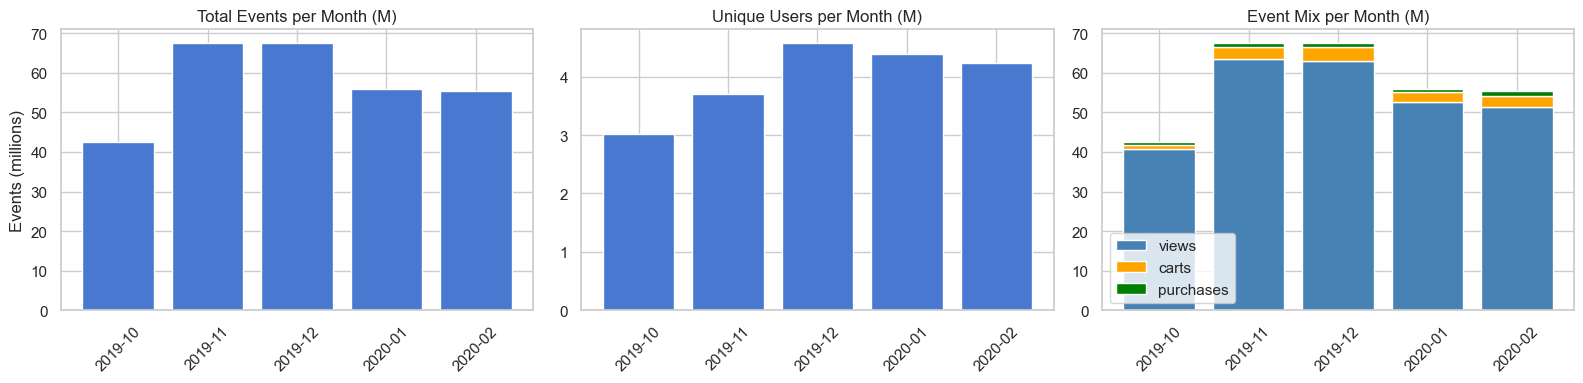

In [21]:
# ── Plot ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].bar(df_area0["month"], df_area0["total_events"] / 1e6)
axes[0].set_title("Total Events per Month (M)")
axes[0].set_ylabel("Events (millions)")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(df_area0["month"], df_area0["unique_users"] / 1e6)
axes[1].set_title("Unique Users per Month (M)")
axes[1].tick_params(axis="x", rotation=45)

bottom = [0] * len(df_area0)
for event, color in [("views","steelblue"), ("carts","orange"), ("purchases","green")]:
    axes[2].bar(df_area0["month"], df_area0[event] / 1e6,
                bottom=bottom, label=event, color=color)
    bottom = [b + v for b, v in zip(bottom, df_area0[event] / 1e6)]
axes[2].set_title("Event Mix per Month (M)")
axes[2].legend()
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [22]:
# ============================================================
# AREA 1: Null & Completeness Audit
# DETERMINISTIC — exact null counts, no thresholds
# PURPOSE: Know exact null % per column; decide handling
#          strategy for category_code, brand, price nulls
# ============================================================
sql_area1 = f"""
SELECT
  COUNT(*)                                            AS total_rows,

  -- Nulls per column
  COUNTIF(event_time    IS NULL)                      AS null_event_time,
  COUNTIF(event_type    IS NULL)                      AS null_event_type,
  COUNTIF(product_id    IS NULL)                      AS null_product_id,
  COUNTIF(category_id   IS NULL)                      AS null_category_id,
  COUNTIF(category_code IS NULL)                      AS null_category_code,
  COUNTIF(brand         IS NULL)                      AS null_brand,
  COUNTIF(price         IS NULL)                      AS null_price,
  COUNTIF(user_id       IS NULL)                      AS null_user_id,
  COUNTIF(user_session  IS NULL)                      AS null_user_session,

  -- Null % per column
  ROUND(COUNTIF(category_code IS NULL) / COUNT(*) * 100, 2) AS pct_null_category_code,
  ROUND(COUNTIF(brand IS NULL)         / COUNT(*) * 100, 2) AS pct_null_brand,
  ROUND(COUNTIF(price IS NULL)         / COUNT(*) * 100, 2) AS pct_null_price,
  ROUND(COUNTIF(user_session IS NULL)  / COUNT(*) * 100, 2) AS pct_null_user_session,

  -- Are nulls in category_code and brand correlated?
  COUNTIF(category_code IS NULL AND brand IS NULL)    AS null_both_cat_brand,
  COUNTIF(category_code IS NULL AND brand IS NOT NULL) AS null_cat_only,
  COUNTIF(category_code IS NOT NULL AND brand IS NULL) AS null_brand_only
FROM `{TABLE_REF}`
"""
df_area1 = run_query(sql_area1, label="area1_nulls")
df_area1.T  # transpose for readability

────────────────────────────────────────────────────────────
  Query  : area1_nulls
  Scan   : 32.03 GB  (~$0.1602)
  ⚠️  Large scan — confirm this is intentional
  Rows   : 1
  Time   : 1.3s
────────────────────────────────────────────────────────────


c:\Users\Patron\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,0
total_rows,288779227
null_event_time,0
null_event_type,0
null_product_id,0
null_category_id,0
null_category_code,52477198
null_brand,38569167
null_price,0
null_user_id,0
null_user_session,66


In [23]:
# ── Are nulls concentrated in specific event types? ─────────
sql_area1b = f"""
SELECT
  event_type,
  COUNT(*)                                                    AS total,
  ROUND(COUNTIF(category_code IS NULL) / COUNT(*) * 100, 2)  AS pct_null_cat_code,
  ROUND(COUNTIF(brand IS NULL)         / COUNT(*) * 100, 2)  AS pct_null_brand,
  ROUND(COUNTIF(price IS NULL)         / COUNT(*) * 100, 2)  AS pct_null_price
FROM `{TABLE_REF}`
GROUP BY event_type
ORDER BY total DESC
"""
df_area1b = run_query(sql_area1b, label="area1_nulls_by_event_type")
df_area1b

────────────────────────────────────────────────────────────
  Query  : area1_nulls_by_event_type
  Scan   : 11.82 GB  (~$0.0591)
  ⚠️  Large scan — confirm this is intentional
  Rows   : 3
  Time   : 0.9s
────────────────────────────────────────────────────────────


c:\Users\Patron\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,event_type,total,pct_null_cat_code,pct_null_brand,pct_null_price
0,view,271045030,18.52,13.72,0.00
1,cart,12877066,13.01,7.99,0.00
2,purchase,4857131,12.53,7.44,0.00


In [24]:
# ============================================================
# AREA 2: Duplicate Detection
# DETERMINISTIC — exact counts, no thresholds
# PURPOSE: Find exact dupes AND near-dupes (same user+product+
#          event within a short time window)
# ============================================================

# ── Exact duplicates (all 9 columns identical) ──────────────
sql_area2_exact = f"""
SELECT
  COUNT(*)                              AS total_rows,
  COUNT(*) - COUNT(DISTINCT
    CONCAT(
      CAST(event_time AS STRING), '|',
      event_type, '|',
      CAST(product_id AS STRING), '|',
      CAST(user_id AS STRING), '|',
      IFNULL(user_session, 'NULL')
    ))                                  AS exact_duplicate_rows,
  ROUND((COUNT(*) - COUNT(DISTINCT
    CONCAT(
      CAST(event_time AS STRING), '|',
      event_type, '|',
      CAST(product_id AS STRING), '|',
      CAST(user_id AS STRING), '|',
      IFNULL(user_session, 'NULL')
    ))) / COUNT(*) * 100, 4)            AS exact_dupe_pct
FROM `{TABLE_REF}`
"""
df_area2_exact = run_query(sql_area2_exact, label="area2_exact_dupes")
df_area2_exact

────────────────────────────────────────────────────────────
  Query  : area2_exact_dupes
  Scan   : 19.66 GB  (~$0.0983)
  ⚠️  Large scan — confirm this is intentional
  Rows   : 1
  Time   : 4.5s
────────────────────────────────────────────────────────────


c:\Users\Patron\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,total_rows,exact_duplicate_rows,exact_dupe_pct
0,288779227,1084384,0.38


In [25]:
# ============================================================
# AREA 3: Price Distribution & Outlier Analysis
# DETERMINISTIC — percentiles give you the data to decide;
#                 actual cutoff is a TODO after seeing numbers
# PURPOSE: Set price floor and ceiling for cleaning
# ============================================================

# ── Percentile distribution ──────────────────────────────────
sql_area3_pct = f"""
SELECT
  MIN(price)                                      AS price_min,
  MAX(price)                                      AS price_max,
  AVG(price)                                      AS price_mean,
  APPROX_QUANTILES(price, 100)[OFFSET(1)]         AS p1,
  APPROX_QUANTILES(price, 100)[OFFSET(5)]         AS p5,
  APPROX_QUANTILES(price, 100)[OFFSET(25)]        AS p25,
  APPROX_QUANTILES(price, 100)[OFFSET(50)]        AS p50,
  APPROX_QUANTILES(price, 100)[OFFSET(75)]        AS p75,
  APPROX_QUANTILES(price, 100)[OFFSET(90)]        AS p90,
  APPROX_QUANTILES(price, 100)[OFFSET(95)]        AS p95,
  APPROX_QUANTILES(price, 100)[OFFSET(99)]        AS p99,
  APPROX_QUANTILES(price, 100)[OFFSET(100)]       AS p100,
  COUNTIF(price IS NULL)                          AS null_price_count,
  COUNTIF(price <= 0)                             AS zero_or_negative_price,
  COUNTIF(price > 10000)                          AS price_gt_10k,
  COUNTIF(price > 50000)                          AS price_gt_50k
FROM `{TABLE_REF}`
"""
df_area3_pct = run_query(sql_area3_pct, label="area3_price_percentiles")
df_area3_pct.T

────────────────────────────────────────────────────────────
  Query  : area3_price_percentiles
  Scan   : 2.31 GB  (~$0.0116)


c:\Users\Patron\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


  Rows   : 1
  Time   : 1.2s
────────────────────────────────────────────────────────────


,0
price_min,0.00
price_max,"2,574.07"
price_mean,286.84
p1,5.12
p5,15.42
p25,64.33
p50,163.45
p75,348.53
p90,743.85
p95,993.59


In [26]:
# ── Price bucket distribution (log-scale histogram proxy) ───
sql_area3_buckets = f"""
SELECT
  CASE
    WHEN price IS NULL       THEN 'NULL'
    WHEN price <= 0          THEN '<=0'
    WHEN price < 1           THEN '0-1'
    WHEN price < 10          THEN '1-10'
    WHEN price < 50          THEN '10-50'
    WHEN price < 100         THEN '50-100'
    WHEN price < 500         THEN '100-500'
    WHEN price < 1000        THEN '500-1k'
    WHEN price < 5000        THEN '1k-5k'
    WHEN price < 10000       THEN '5k-10k'
    ELSE '>10k'
  END                        AS price_bucket,
  COUNT(*)                   AS event_count,
  COUNT(DISTINCT product_id) AS unique_products
FROM `{TABLE_REF}`
GROUP BY price_bucket
ORDER BY MIN(IFNULL(price, -1))
"""
df_area3_buckets = run_query(sql_area3_buckets, label="area3_price_buckets")
df_area3_buckets

────────────────────────────────────────────────────────────
  Query  : area3_price_buckets
  Scan   : 4.62 GB  (~$0.0231)
  Rows   : 8
  Time   : 1.2s
────────────────────────────────────────────────────────────


c:\Users\Patron\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,price_bucket,event_count,unique_products
0,<=0,583466,68107
1,0-1,43277,456
2,1-10,7802137,48089
3,10-50,48562698,103673
4,50-100,43975151,64014
5,100-500,139587503,94908
6,500-1k,33959635,17433
7,1k-5k,14265360,8362


In [11]:
# TODO — AFTER SEEING RESULTS:
# Set these two thresholds based on percentile output above:
#   PRICE_FLOOR   = ???   # likely 0 or a small positive value
#   PRICE_CEILING = ???   # look at p99 vs p100 gap — that gap tells you
#                         # whether there are extreme outliers worth capping
# Common approach: keep prices between p0.5 and p99.5, or use a
# domain-based ceiling (e.g., $10,000 for eCommerce makes sense).
# Document your decision in docs/eda_findings.md

In [31]:
'''
PRICE_FLOOR   = 1.0   # drop price <= 0 (583k rows) and sub-$1 noise (43k rows)
                      # p1 = $5.12 confirms $1 floor is conservative, not aggressive
PRICE_CEILING = None  # no ceiling needed — p100 = $2,574, no extreme outliers exist
                      # max price is only 51% above p99, well within normal range
'''

'\nPRICE_FLOOR   = 1.0   # drop price <= 0 (583k rows) and sub-$1 noise (43k rows)\n                      # p1 = $5.12 confirms $1 floor is conservative, not aggressive\nPRICE_CEILING = None  # no ceiling needed — p100 = $2,574, no extreme outliers exist\n                      # max price is only 51% above p99, well within normal range\n'

In [28]:
# ============================================================
# AREA 4: User Activity Distribution — Bot Detection
# DETERMINISTIC PART: compute per-user stats
# THRESHOLD PART: bot cutoff is a TODO after seeing distribution
# MODELING RELEVANCE: 5-core viability for ALS/BPR
# ============================================================

# ── Per-user event counts + active days ─────────────────────
sql_area4_dist = f"""
SELECT
  total_events_bucket,
  COUNT(*) AS user_count
FROM (
  SELECT
    user_id,
    COUNT(*) AS total_events,
    CASE
      WHEN COUNT(*) = 1          THEN '1'
      WHEN COUNT(*) <= 4         THEN '2-4'
      WHEN COUNT(*) <= 9         THEN '5-9'
      WHEN COUNT(*) <= 19        THEN '10-19'
      WHEN COUNT(*) <= 49        THEN '20-49'
      WHEN COUNT(*) <= 99        THEN '50-99'
      WHEN COUNT(*) <= 499       THEN '100-499'
      WHEN COUNT(*) <= 999       THEN '500-999'
      WHEN COUNT(*) <= 4999      THEN '1k-5k'
      WHEN COUNT(*) <= 9999      THEN '5k-10k'
      ELSE '>10k'
    END AS total_events_bucket
  FROM `{TABLE_REF}`
  GROUP BY user_id
)
GROUP BY total_events_bucket
ORDER BY MIN(
  CASE total_events_bucket
    WHEN '1'       THEN 1
    WHEN '2-4'     THEN 2
    WHEN '5-9'     THEN 5
    WHEN '10-19'   THEN 10
    WHEN '20-49'   THEN 20
    WHEN '50-99'   THEN 50
    WHEN '100-499' THEN 100
    WHEN '500-999' THEN 500
    WHEN '1k-5k'   THEN 1000
    WHEN '5k-10k'  THEN 5000
    ELSE 10001
  END
)
"""
df_area4_dist = run_query(sql_area4_dist, label="area4_user_event_dist")
df_area4_dist

────────────────────────────────────────────────────────────
  Query  : area4_user_event_dist
  Scan   : 2.31 GB  (~$0.0116)
  Rows   : 11
  Time   : 1.4s
────────────────────────────────────────────────────────────


c:\Users\Patron\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,total_events_bucket,user_count
0,1,2872363
1,2-4,3054095
2,5-9,1746055
3,10-19,1390351
4,20-49,1411651
5,50-99,710552
6,100-499,611936
7,500-999,34568
8,1k-5k,8267
9,5k-10k,92


In [29]:
# ── Events-per-day distribution (bot signal) ─────────────────
sql_area4_epd = f"""
SELECT
  epd_bucket,
  COUNT(*) AS user_count
FROM (
  SELECT
    user_id,
    COUNT(*) / COUNT(DISTINCT DATE(event_time)) AS events_per_day,
    CASE
      WHEN COUNT(*) / COUNT(DISTINCT DATE(event_time)) <= 10    THEN '1-10'
      WHEN COUNT(*) / COUNT(DISTINCT DATE(event_time)) <= 50    THEN '11-50'
      WHEN COUNT(*) / COUNT(DISTINCT DATE(event_time)) <= 100   THEN '51-100'
      WHEN COUNT(*) / COUNT(DISTINCT DATE(event_time)) <= 200   THEN '101-200'
      WHEN COUNT(*) / COUNT(DISTINCT DATE(event_time)) <= 500   THEN '201-500'
      WHEN COUNT(*) / COUNT(DISTINCT DATE(event_time)) <= 1000  THEN '501-1k'
      ELSE '>1k'
    END AS epd_bucket
  FROM `{TABLE_REF}`
  GROUP BY user_id
)
GROUP BY epd_bucket
ORDER BY MIN(
  CASE epd_bucket
    WHEN '1-10'    THEN 1
    WHEN '11-50'   THEN 11
    WHEN '51-100'  THEN 51
    WHEN '101-200' THEN 101
    WHEN '201-500' THEN 201
    WHEN '501-1k'  THEN 501
    ELSE 1001
  END
)
"""
df_area4_epd = run_query(sql_area4_epd, label="area4_events_per_day")
df_area4_epd

────────────────────────────────────────────────────────────
  Query  : area4_events_per_day
  Scan   : 4.62 GB  (~$0.0231)
  Rows   : 7
  Time   : 2.7s
────────────────────────────────────────────────────────────


c:\Users\Patron\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,epd_bucket,user_count
0,1-10,10654902
1,11-50,1157559
2,51-100,20483
3,101-200,5175
4,201-500,1800
5,501-1k,13
6,>1k,32


In [30]:
# ── 5-core viability: how many users survive at each threshold?
sql_area4_core = f"""
SELECT
  min_interactions,
  COUNT(*) AS users_surviving,
  ROUND(COUNT(*) / MAX(COUNT(*)) OVER () * 100, 2) AS pct_surviving
FROM (
  SELECT user_id, COUNT(*) AS interaction_count
  FROM `{TABLE_REF}`
  GROUP BY user_id
), UNNEST([1, 2, 3, 5, 10, 20]) AS min_interactions
WHERE interaction_count >= min_interactions
GROUP BY min_interactions
ORDER BY min_interactions
"""
df_area4_core = run_query(sql_area4_core, label="area4_core_viability")
df_area4_core

────────────────────────────────────────────────────────────
  Query  : area4_core_viability
  Scan   : 2.31 GB  (~$0.0116)
  Rows   : 6
  Time   : 1.5s
────────────────────────────────────────────────────────────


c:\Users\Patron\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\cloud\bigquery\table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,min_interactions,users_surviving,pct_surviving
0,1,11839964,100.00
1,2,8967601,75.74
2,3,7593911,64.14
3,5,5913506,49.95
4,10,4167451,35.20
5,20,2777100,23.46


In [ ]:
# TODO — AFTER SEEING RESULTS:
# BOT_THRESHOLD_EPD = ???
# Look at the events-per-day distribution. You're looking for a
# "natural break" — a gap between normal heavy users and obvious
# bots. Typical eCommerce bot thresholds: 200–1000 events/day.
# The right answer is where the distribution has a clear inflection.
#
# Also note from df_area4_core: if <60% of users survive 5-core
# filtering, consider dropping to 3-core. If >85% survive,
# 5-core is very conservative and you may want to raise it.

In [ ]:
BOT_THRESHOLD_EVENTS_PER_DAY = 200
# Removes 1,845 users (0.016% of user base)
# Natural break: 1.15M users at 11-50 epd vs 20K at 51-100 — 56x drop

CORE_K = 3
# Retains 5,913,506 users (49.95% of raw user base)
# Removes single-interaction and very sparse users — correct for ALS/BPR quality

In [33]:
# Add this as a new cell after your Area 11 results

k_values    = [1, 2, 3, 5, 10, 20]
users       = [11839964, 8967601, 7593911, 5913506, 4167451, 2777100]
pct         = [100.00,   75.74,   64.14,   49.95,   35.20,   23.46]

# Marginal cost: how many users do you lose per unit increase in k?
print("Marginal user loss per k step:")
for i in range(1, len(k_values)):
    delta_k     = k_values[i] - k_values[i-1]
    delta_users = users[i-1] - users[i]
    print(f"  k={k_values[i-1]}→{k_values[i]}: "
          f"lose {delta_users:,} users "
          f"({pct[i-1]-pct[i]:.1f}% of base) "
          f"over {delta_k} k-units")

Marginal user loss per k step:
  k=1→2: lose 2,872,363 users (24.3% of base) over 1 k-units
  k=2→3: lose 1,373,690 users (11.6% of base) over 1 k-units
  k=3→5: lose 1,680,405 users (14.2% of base) over 2 k-units
  k=5→10: lose 1,746,055 users (14.8% of base) over 5 k-units
  k=10→20: lose 1,390,351 users (11.7% of base) over 10 k-units
